<a href="https://colab.research.google.com/github/leonardb-bacon/ECE2112_PA4/blob/main/Fa4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('board2.csv')
df.columns = df.columns.str.strip()


subject_cols = ['Math', 'Electronics', 'GEAS', 'Communication']
df['Average'] = df[subject_cols].mean(axis=1)

print("Dataset loaded and 'Average' column calculated successfully!")
print(df.columns.tolist())

Dataset loaded and 'Average' column calculated successfully!
['Name', 'Gender', 'Track', 'Hometown', 'Math', 'Electronics', 'GEAS', 'Communication', 'Average']


In [13]:
# PART A: VISAYAS COMMUNICATION DATAFRAME
VisConn = df[(df['Hometown'] == 'Visayas') & (df['Track'] == 'Communication')][[
    'Name', 'Gender', 'Track', 'Hometown', 'Math', 'GEAS', 'Electronics', 'Average'
    ]]
print(VisConn)
print("Number of rows:", len(VisConn))

   Name  Gender          Track Hometown  Math  GEAS  Electronics  Average
10  S11  Female  Communication  Visayas    48    48           56    54.75
11  S12    Male  Communication  Visayas    89    84           67    76.00
17  S18    Male  Communication  Visayas    81    81           40    63.50
21  S22  Female  Communication  Visayas    64    89           39    62.50
27  S28    Male  Communication  Visayas    85    80           53    67.75
Number of rows: 5


In [15]:
# PART B: VISAYAS FEMALE DATAFRAME
VisFemale = df[(df['Hometown'] == 'Visayas') & (df['Gender'] == 'Female')][[
    'Name', 'Track', 'GEAS', 'Electronics', 'Average'
    ]]
print("VisFemale DataFrame:")
print(VisFemale)

    # Filter rows where Average >= 60 without overwriting VisFemale
vis_female_passing = VisFemale[VisFemale['Average'] >= 60]
print("\nVisFemale with Average >= 60:")
print(vis_female_passing)

VisFemale DataFrame:
   Name             Track  GEAS  Electronics  Average
5    S6  Microelectronics    86           45    75.50
10  S11     Communication    48           56    54.75
20  S21  Microelectronics    68           51    68.50
21  S22     Communication    89           39    62.50
23  S24  Microelectronics    60           45    57.75
25  S26   Instrumentation    83           47    65.75

VisFemale with Average >= 60:
   Name             Track  GEAS  Electronics  Average
5    S6  Microelectronics    86           45    75.50
20  S21  Microelectronics    68           51    68.50
21  S22     Communication    89           39    62.50
25  S26   Instrumentation    83           47    65.75


--- Track Means ---
              Track  Average
0     Communication   67.975
1   Instrumentation   65.225
2  Microelectronics   67.500

--- Gender Means ---
   Gender    Average
0  Female  66.616667
1    Male  67.183333

--- Hometown Means ---
   Hometown    Average
0     Luzon  68.083333
1  Mindanao  66.678571
2   Visayas  65.750000


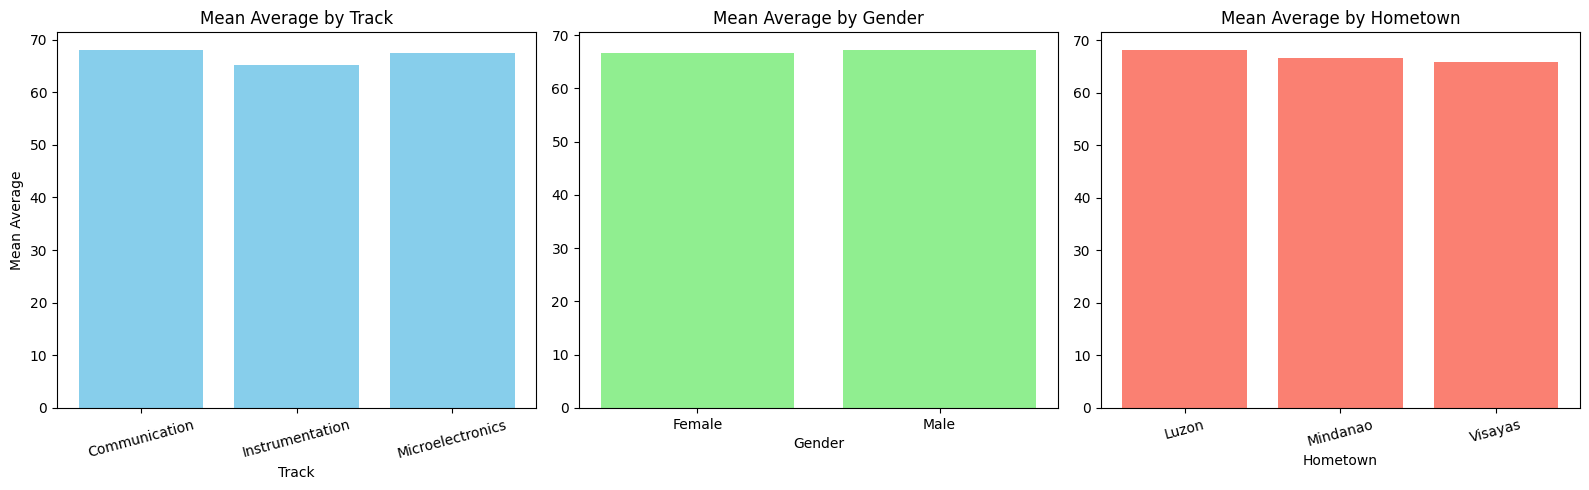

In [16]:
# PART C: CATEGORY-AVERAGE VISUALIZATION
track_mean = df.groupby('Track')['Average'].mean().reset_index()
gender_mean = df.groupby('Gender')['Average'].mean().reset_index()
hometown_mean = df.groupby('Hometown')['Average'].mean().reset_index()

print("--- Track Means ---")
print(track_mean)
print("\n--- Gender Means ---")
print(gender_mean)
print("\n--- Hometown Means ---")
print(hometown_mean)

# Create bar charts
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(track_mean['Track'], track_mean['Average'], color='skyblue')
axes[0].set_title('Mean Average by Track')
axes[0].set_xlabel('Track')
axes[0].set_ylabel('Mean Average')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(gender_mean['Gender'], gender_mean['Average'], color='lightgreen')
axes[1].set_title('Mean Average by Gender')
axes[1].set_xlabel('Gender')

axes[2].bar(hometown_mean['Hometown'], hometown_mean['Average'], color='salmon')
axes[2].set_title('Mean Average by Hometown')
axes[2].set_xlabel('Hometown')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()